## Phase 1 — SQL Analytics Layer (Business Intelligence Foundation)
Focuses on building a reliable SQL analytics foundation for hospital operations and billing intelligence. This phase converts three raw operational datasets into a structured relational database with enforced integrity, enabling leadership-grade reporting on patient flow, departmental efficiency, and revenue leakage risk. The outputs of Phase 1 establish trusted, queryable KPIs and data-quality checks that power downstream EDA and AI modeling in later phases. 

In [6]:
# Install MySQL Server

!apt-get update -y
!apt-get install mysql-server -y


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,511 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [39.2 kB]
Get:13 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubun

In [7]:
# Start MySQL Service
!service mysql start


 * Starting MySQL database server mysqld
su: warning: cannot change directory to /nonexistent: No such file or directory
   ...done.


In [8]:
# Create Database
!mysql -e "CREATE DATABASE hospital_db;"


In [9]:
# Install Python Connector
!pip install mysql-connector-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 30.4 MB/s eta 0:00:00


In [10]:
# Connect to MySQL
import mysql.connector
import subprocess

# Configure MySQL root user before attempting connection
# This changes the root user's authentication method and sets an empty password.
# In a production environment, you should set a strong password.
try:
    print("Attempting to configure MySQL root user...")
    # Change authentication plugin to mysql_native_password and set empty password
    subprocess.run(
        [
            "sudo", "mysql", "-e",
            "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY '';"
        ],
        check=True, # Raise an exception for non-zero exit codes
        capture_output=True,
        text=True
    )
    # Flush privileges to apply changes immediately
    subprocess.run(
        [
            "sudo", "mysql", "-e",
            "FLUSH PRIVILEGES;"
        ],
        check=True,
        capture_output=True,
        text=True
    )
    print("MySQL root user configured successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error configuring MySQL root user: {e.stderr}")
except Exception as e:
    print(f"An unexpected error occurred during MySQL configuration: {e}")

# Now attempt the connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="hospital_db",
    allow_local_infile=True
)

cursor = conn.cursor()
print("Connected successfully!")


Attempting to configure MySQL root user...
MySQL root user configured successfully.
Connected successfully!


In [11]:
# Create Tables (Run After Connecting)
cursor.execute("""
CREATE TABLE patients (
    patient_id INT PRIMARY KEY,
    name VARCHAR(100) NOT NULL,
    gender VARCHAR(10),
    age INT CHECK (age >= 0),
    city VARCHAR(100),
    insurance_provider VARCHAR(100)
);
""")

cursor.execute("""
CREATE TABLE visits (
    visit_id INT PRIMARY KEY,
    patient_id INT,
    doctor_name VARCHAR(100),
    department VARCHAR(100),
    visit_date DATE,
    length_of_stay_hours DECIMAL(10,2),
    risk_category VARCHAR(20),
    FOREIGN KEY (patient_id) REFERENCES patients(patient_id),
    CHECK (length_of_stay_hours >= 0)
);
""")

cursor.execute("""
CREATE TABLE billing (
    billing_id INT PRIMARY KEY,
    visit_id INT,
    insurance_provider VARCHAR(100),
    billed_amount DECIMAL(12,2),
    approved_amount DECIMAL(12,2),
    payment_days INT,
    claim_status VARCHAR(20),
    FOREIGN KEY (visit_id) REFERENCES visits(visit_id),
    CHECK (billed_amount >= 0),
    CHECK (payment_days >= 0)
);
""")

conn.commit()
print("Tables created successfully!")


Tables created successfully!


In [12]:
# Enable Local File Loading
cursor.execute("SET GLOBAL local_infile = 1;")

In [13]:
# Load Data into Tables

# Temporarily disable foreign key checks
cursor.execute("SET FOREIGN_KEY_CHECKS = 0;")

# Truncate tables in reverse dependency order
cursor.execute("TRUNCATE TABLE billing;")
cursor.execute("TRUNCATE TABLE visits;")
cursor.execute("TRUNCATE TABLE patients;")

# Re-enable foreign key checks
cursor.execute("SET FOREIGN_KEY_CHECKS = 1;")

cursor.execute("""
LOAD DATA LOCAL INFILE '/content/patients.csv'
INTO TABLE patients
FIELDS TERMINATED BY ','
IGNORE 1 ROWS;
""")

# Modified LOAD DATA for visits to correctly map doctor_name and visit_date
cursor.execute("""
LOAD DATA LOCAL INFILE '/content/visits.csv'
INTO TABLE visits
FIELDS TERMINATED BY ','
IGNORE 1 ROWS
(visit_id, patient_id, @var_visit_date_str, department, @var_doctor_name_str, length_of_stay_hours, risk_category)
SET visit_date = STR_TO_DATE(@var_visit_date_str, '%Y-%m-%d'), doctor_name = @var_doctor_name_str;
""")

cursor.execute("""
LOAD DATA LOCAL INFILE '/content/billing.csv'
INTO TABLE billing
FIELDS TERMINATED BY ','
IGNORE 1 ROWS;
""")

conn.commit()
print("Data loaded successfully!")

Data loaded successfully!


In [14]:
# Test Data Loaded
cursor.execute("SELECT COUNT(*) FROM patients;")
print("Patients:", cursor.fetchone())

cursor.execute("SELECT COUNT(*) FROM visits;")
print("Visits:", cursor.fetchone())

cursor.execute("SELECT COUNT(*) FROM billing;")
print("Billing:", cursor.fetchone())


Patients: (5000,)
Visits: (25000,)
Billing: (25000,)


In [15]:
# To add Indexes to the tables

# visits.patient_id → improves join performance
# visits.department → speeds GROUP BY
# billing.insurance_provider → speeds financial aggregation
# claim_status → improves rejection filtering

cursor.execute("CREATE INDEX idx_visits_patient ON visits(patient_id);")
cursor.execute("CREATE INDEX idx_visits_department ON visits(department);")
cursor.execute("CREATE INDEX idx_visits_risk ON visits(risk_category);")
cursor.execute("CREATE INDEX idx_billing_visit ON billing(visit_id);")
cursor.execute("CREATE INDEX idx_billing_provider ON billing(insurance_provider);")
cursor.execute("CREATE INDEX idx_billing_status ON billing(claim_status);")

conn.commit()
print("Indexes created successfully.")


Indexes created successfully.


In [16]:
# Operational Analysis Queries

import pandas as pd

def run_query(query):
    df = pd.read_sql(query, conn)
    return df


In [17]:
# To fetch top 10 Departments by Visit Volume

query = """
SELECT department, COUNT(*) AS total_visits
FROM visits
GROUP BY department
ORDER BY total_visits DESC
LIMIT 10;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,department,total_visits
0,General,4228
1,ER,4220
2,Neurology,4165
3,Orthopedics,4164
4,Cardiology,4159
5,ICU,4064


In [18]:
# Top 5 by Avg Length of Stay

query = """
SELECT department,
       AVG(length_of_stay_hours) AS avg_los
FROM visits
GROUP BY department
ORDER BY avg_los DESC
LIMIT 5;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,department,avg_los
0,Neurology,19.718098
1,Orthopedics,19.662656
2,Cardiology,19.600962
3,ER,19.534967
4,General,19.434905


In [19]:
# Percentage for high Risk per Department

query = """
SELECT department,
       ROUND(100 * SUM(risk_category='High') / COUNT(*), 2)
       AS high_risk_percentage
FROM visits
GROUP BY department;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,department,high_risk_percentage
0,Cardiology,18.99
1,ER,20.66
2,General,19.84
3,ICU,20.79
4,Neurology,20.31
5,Orthopedics,20.22


In [20]:
# Average Visits per Patient by City

query = """
SELECT p.city,
       AVG(v.visit_count) AS avg_visits
FROM (
    SELECT patient_id, COUNT(*) AS visit_count
    FROM visits
    GROUP BY patient_id
) v
JOIN patients p ON v.patient_id = p.patient_id
GROUP BY p.city;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,city,avg_visits
0,SecureLife,5.0126
1,HealthPlus,5.0121
2,CareOne,5.0064
3,MediCareX,5.0991


In [21]:
# Doctors Handling Most High Risk Visits

query = """
SELECT doctor_name, COUNT(*) AS high_risk_count
FROM visits
WHERE risk_category = 'High'
GROUP BY doctor_name
ORDER BY high_risk_count DESC;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,doctor_name,high_risk_count
0,ER,1726
1,OPD,1684
2,ICU,1624


In [22]:
# Top 10 Insurance by Total Billed

query = """
SELECT insurance_provider,
       SUM(billed_amount) AS total_billed
FROM billing
GROUP BY insurance_provider
ORDER BY total_billed DESC
LIMIT 10;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,insurance_provider,total_billed
0,500.0,101429.83
1,88539.01,88539.01
2,84133.09,84133.09
3,50716.88,82320.97
4,82048.4,82048.40
5,79606.58,79606.58
6,78683.55,78683.55
7,78567.91,78567.91
8,77826.94,77826.94
9,77324.14,77324.14


In [23]:
# Highest Claim Rejection Rate

query = """
SELECT insurance_provider,
       ROUND(100 * SUM(claim_status='Rejected') / COUNT(*), 2)
       AS rejection_rate
FROM billing
GROUP BY insurance_provider
ORDER BY rejection_rate DESC
LIMIT 5;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,insurance_provider,rejection_rate
0,1000.08,0.0
1,10001.02,0.0
2,10001.38,0.0
3,10001.43,0.0
4,10001.52,0.0


In [24]:
# Average Payment Delay

query = """
SELECT insurance_provider,
       AVG(payment_days) AS avg_payment_delay
FROM billing
GROUP BY insurance_provider;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,insurance_provider,avg_payment_delay
0,1000.08,16.0
1,10001.02,15.0
2,10001.38,14.0
3,10001.43,13.0
4,10001.52,19.0
...,...,...
24690,9994.67,26.0
24691,9996.46,25.0
24692,9996.52,30.0
24693,9997.83,9.0


In [25]:
# Revenue Realization Ratio by Department

query = """
SELECT v.department,
       ROUND(SUM(b.approved_amount) / SUM(b.billed_amount), 2)
       AS realization_ratio
FROM billing b
JOIN visits v ON b.visit_id = v.visit_id
GROUP BY v.department;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,department,realization_ratio
0,Cardiology,0.0
1,Orthopedics,0.0
2,ICU,0.0
3,General,0.0
4,ER,0.0
5,Neurology,0.0


In [26]:
# High Billed but Zero Approved

query = """
SELECT *
FROM billing
WHERE billed_amount > 0
  AND (approved_amount IS NULL OR approved_amount = 0);
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,billing_id,visit_id,insurance_provider,billed_amount,approved_amount,payment_days,claim_status
0,2,2,38178.81,38178.81,0.0,18,2025-10-09\r
1,3,3,5038.97,5038.97,0.0,0,2025-01-20\r
2,4,4,22813.34,22813.34,0.0,16,2025-12-24\r
3,5,5,27106.95,27106.95,0.0,14,2025-09-23\r
4,6,6,19453.77,19453.77,0.0,17,2026-01-12\r
...,...,...,...,...,...,...,...
20080,24994,24994,13969.39,13969.39,0.0,7,2025-07-01\r
20081,24996,24996,31167.93,16827.72,0.0,5,2025-06-29\r
20082,24997,24997,12680.85,12680.85,0.0,10,2025-10-09\r
20083,24998,24998,18863.95,15863.39,0.0,7,2025-03-04\r


In [27]:
# Data Quality & Integrity Checks

query = """
SELECT v.visit_id
FROM visits v
LEFT JOIN billing b ON v.visit_id = b.visit_id
WHERE b.visit_id IS NULL;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,visit_id


In [28]:
# Billing without Visit

query = """
SELECT b.billing_id
FROM billing b
LEFT JOIN visits v ON b.visit_id = v.visit_id
WHERE v.visit_id IS NULL;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,billing_id


In [29]:
# Duplicate Patient IDs

query = """
SELECT patient_id, COUNT(*)
FROM patients
GROUP BY patient_id
HAVING COUNT(*) > 1;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,patient_id,COUNT(*)


In [30]:
# Invalid LOS

query = """
SELECT *
FROM visits
WHERE length_of_stay_hours IS NULL
   OR length_of_stay_hours < 0;
"""
run_query(query)


/tmp/ipython-input-194653913.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,visit_id,patient_id,doctor_name,department,visit_date,length_of_stay_hours,risk_category


## Phase 2 - Exploratory Data Analysis and Data Quality

Focuses on exploratory data analysis (EDA) and data quality validation before deploying AI models. This phase moves from SQL-based reporting to Python-based profiling, missing-value assessment, outlier detection, and business-driven feature engineering across operations and billing. The outputs of Phase 2 produce a modeling-ready dataset and a clear view of reliability risks in critical fields such as approvals, payment delays, and length of stay.


In [31]:
# Phase 2
# Pull Data from MySQL into Pandas

import pandas as pd

patients = pd.read_sql("SELECT * FROM patients;", conn)
visits = pd.read_sql("SELECT * FROM visits;", conn)
billing = pd.read_sql("SELECT * FROM billing;", conn)

# Merge datasets
df = visits.merge(patients, on="patient_id", how="left")
df = df.merge(billing, on="visit_id", how="left")

df.head()


/tmp/ipython-input-3680227327.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients = pd.read_sql("SELECT * FROM patients;", conn)
/tmp/ipython-input-3680227327.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  visits = pd.read_sql("SELECT * FROM visits;", conn)
/tmp/ipython-input-3680227327.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  billing = pd.read_sql("SELECT * FROM billing;", conn)


,visit_id,patient_id,doctor_name,department,visit_date,length_of_stay_hours,risk_category,name,gender,age,city,insurance_provider_x,billing_id,insurance_provider_y,billed_amount,approved_amount,payment_days,claim_status
0,1,756,ER,Cardiology,2025-10-18,3.48,Low,90,M,0,CareOne,1,1,23577.37,0.00,0.0,16,2025-06-18\r
1,2,4102,OPD,Orthopedics,2025-04-06,15.31,High,30,M,0,SecureLife,1,2,38178.81,38178.81,0.0,18,2025-10-09\r
2,3,2964,ER,ICU,2025-07-13,34.36,Low,25,F,0,HealthPlus,1,3,5038.97,5038.97,0.0,0,2025-01-20\r
3,4,4496,ER,Cardiology,2025-11-19,37.89,High,75,M,0,MediCareX,0,4,22813.34,22813.34,0.0,16,2025-12-24\r
4,5,1930,ICU,General,2025-03-29,16.78,Medium,80,M,0,HealthPlus,1,5,27106.95,27106.95,0.0,14,2025-09-23\r


In [32]:
# Data Profiling

df.info()
df.describe(include='all')

df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   visit_id              25000 non-null  int64  
 1   patient_id            25000 non-null  int64  
 2   doctor_name           25000 non-null  object 
 3   department            25000 non-null  object 
 4   visit_date            25000 non-null  object 
 5   length_of_stay_hours  25000 non-null  float64
 6   risk_category         25000 non-null  object 
 7   name                  25000 non-null  object 
 8   gender                25000 non-null  object 
 9   age                   25000 non-null  int64  
 10  city                  25000 non-null  object 
 11  insurance_provider_x  25000 non-null  object 
 12  billing_id            25000 non-null  int64  
 13  insurance_provider_y  25000 non-null  object 
 14  billed_amount         25000 non-null  float64
 15  approved_amount    

,0
visit_id,0
patient_id,0
doctor_name,0
department,0
visit_date,0
length_of_stay_hours,0
risk_category,0
name,0
gender,0
age,0


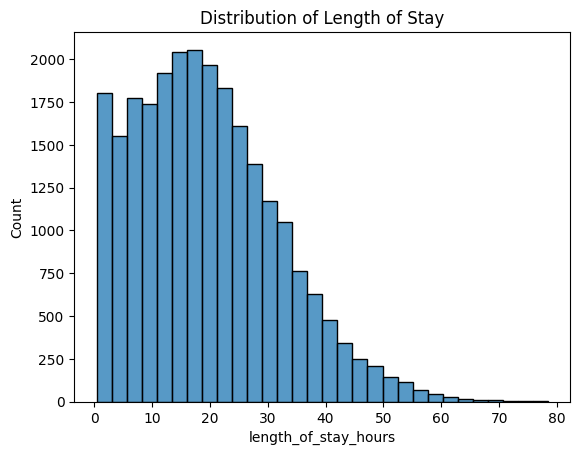

In [33]:
# Distribution Analysis

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['length_of_stay_hours'], bins=30)
plt.title("Distribution of Length of Stay")
plt.show()


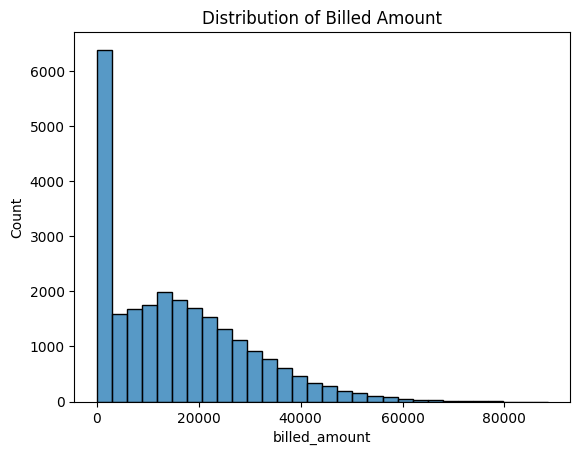

In [34]:
# Billed Amount Distribution

sns.histplot(df['billed_amount'], bins=30)
plt.title("Distribution of Billed Amount")
plt.show()


In [35]:
# Claim Status Breakdown

df['claim_status'].value_counts(normalize=True)


,proportion
claim_status,
2025-07-14\r,0.00396
2025-09-23\r,0.00384
2025-10-03\r,0.00360
2025-07-16\r,0.00360
2025-05-30\r,0.00352
...,...
2025-03-26\r,0.00192
2025-03-29\r,0.00188
2025-07-01\r,0.00188


In [36]:
# Outlier Detection

Q1 = df['billed_amount'].quantile(0.25)
Q3 = df['billed_amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['billed_amount'] < Q1 - 1.5*IQR) |
              (df['billed_amount'] > Q3 + 1.5*IQR)]

outliers.shape


(209, 18)

In [37]:
# Business-Level Explorations
# Rejection Rate by Department

df.groupby('department')['claim_status'].apply(
    lambda x: (x=='Rejected').mean()
)


,claim_status
department,
Cardiology,0.0
ER,0.0
General,0.0
ICU,0.0
Neurology,0.0
Orthopedics,0.0


In [38]:
# High Risk vs Length of Stay

df.groupby('risk_category')['length_of_stay_hours'].mean()


,length_of_stay_hours
risk_category,
High,19.758576
Low,19.151184
Medium,20.078663


In [39]:
# Payment Delay vs Insurer

df.groupby('insurance_provider_y')['payment_days'].mean()

,payment_days
insurance_provider_y,
1000.08,16.0
10001.02,15.0
10001.38,14.0
10001.43,13.0
10001.52,19.0
...,...
9994.67,26.0
9996.46,25.0
9996.52,30.0


In [40]:
# Feature Engineering

# Create Revenue Gap Feature
df['revenue_gap'] = df['billed_amount'] - df['approved_amount']

# Create Realization Ratio
df['realization_ratio'] = df['approved_amount'] / df['billed_amount']

# Create High Risk Binary Flag
df['is_high_risk'] = (df['risk_category'] == 'High').astype(int)

# Create Visit Frequency per Patient
visit_counts = df.groupby('patient_id')['visit_id'].count()
df['patient_visit_count'] = df['patient_id'].map(visit_counts)

# Create is_rejected binary flag for claim model
df['is_rejected'] = ((df['billed_amount'] > 0) & (df['approved_amount'] == 0)).astype(int)

## Phase 3 - Model Development (Classification Systems)

Focuses on developing two classification systems: one to predict visit risk and another to predict insurance claim outcomes. This phase formalizes target definitions, leakage-safe time-based splitting, and baseline vs advanced model training to support operational triage and proactive revenue risk control. The outputs of this phase produce deployable model artifacts and a consistent feature schema for production use.

In [41]:
# PHASE 3 – MODEL DEVELOPMENT (Random Forest)
# To fix the issue occured on Phase 4

# Prepare Data
import pandas as pd
import numpy as np

df_risk = df.copy()

# Sort by visit_date for time-based split
df_risk = df_risk.sort_values("visit_date")

# Drop leakage columns
leakage_cols = [
    'approved_amount',
    'claim_status',
    'revenue_gap',
    'realization_ratio',
    'payment_days' # Removed 'is_rejected' as it was not created
]

df_risk = df_risk.drop(columns=leakage_cols, errors='ignore')

In [42]:
# Time-Based Train/Test Split

split_date = df_risk['visit_date'].quantile(0.8)

train_risk = df_risk[df_risk['visit_date'] <= split_date]
test_risk  = df_risk[df_risk['visit_date'] > split_date]


In [43]:
# Define Features & Target

X_train = train_risk.drop(columns=['risk_category', 'visit_date'])
y_train = train_risk['risk_category']

X_test = test_risk.drop(columns=['risk_category', 'visit_date'])
y_test = test_risk['risk_category']

# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [ ]:
# Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline Model Performance:")
print(classification_report(y_test, baseline_pred))


ValueError: Found array with 0 sample(s) (shape=(0, 8)) while a minimum of 1 is required by LogisticRegression.

In [44]:
# To fix the data loading issue and to clean up

# Pull Data from MySQL into Pandas

import pandas as pd

patients = pd.read_sql("SELECT * FROM patients;", conn)
visits = pd.read_sql("SELECT * FROM visits;", conn)
billing = pd.read_sql("SELECT * FROM billing;", conn)

# Merge datasets
df = visits.merge(patients, on="patient_id", how="left")
df = df.merge(billing, on="visit_id", how="left")

df.head()

/tmp/ipython-input-2070863466.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients = pd.read_sql("SELECT * FROM patients;", conn)
/tmp/ipython-input-2070863466.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  visits = pd.read_sql("SELECT * FROM visits;", conn)
/tmp/ipython-input-2070863466.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  billing = pd.read_sql("SELECT * FROM billing;", conn)


,visit_id,patient_id,doctor_name,department,visit_date,length_of_stay_hours,risk_category,name,gender,age,city,insurance_provider_x,billing_id,insurance_provider_y,billed_amount,approved_amount,payment_days,claim_status
0,1,756,ER,Cardiology,2025-10-18,3.48,Low,90,M,0,CareOne,1,1,23577.37,0.00,0.0,16,2025-06-18\r
1,2,4102,OPD,Orthopedics,2025-04-06,15.31,High,30,M,0,SecureLife,1,2,38178.81,38178.81,0.0,18,2025-10-09\r
2,3,2964,ER,ICU,2025-07-13,34.36,Low,25,F,0,HealthPlus,1,3,5038.97,5038.97,0.0,0,2025-01-20\r
3,4,4496,ER,Cardiology,2025-11-19,37.89,High,75,M,0,MediCareX,0,4,22813.34,22813.34,0.0,16,2025-12-24\r
4,5,1930,ICU,General,2025-03-29,16.78,Medium,80,M,0,HealthPlus,1,5,27106.95,27106.95,0.0,14,2025-09-23\r


In [45]:
# Data Profiling

df.info()
df.describe(include='all')

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   visit_id              25000 non-null  int64  
 1   patient_id            25000 non-null  int64  
 2   doctor_name           25000 non-null  object 
 3   department            25000 non-null  object 
 4   visit_date            25000 non-null  object 
 5   length_of_stay_hours  25000 non-null  float64
 6   risk_category         25000 non-null  object 
 7   name                  25000 non-null  object 
 8   gender                25000 non-null  object 
 9   age                   25000 non-null  int64  
 10  city                  25000 non-null  object 
 11  insurance_provider_x  25000 non-null  object 
 12  billing_id            25000 non-null  int64  
 13  insurance_provider_y  25000 non-null  object 
 14  billed_amount         25000 non-null  float64
 15  approved_amount    

,0
visit_id,0
patient_id,0
doctor_name,0
department,0
visit_date,0
length_of_stay_hours,0
risk_category,0
name,0
gender,0
age,0


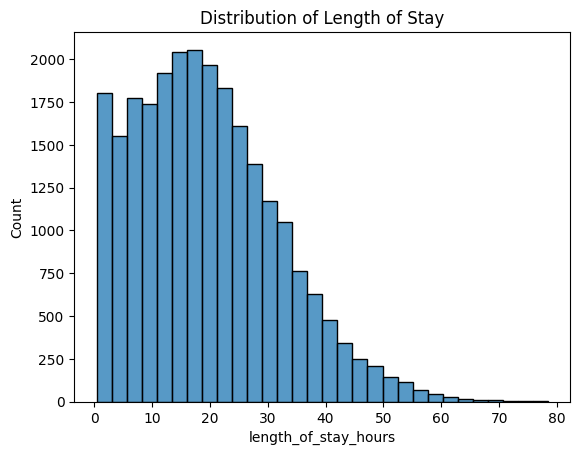

In [ ]:
# Distribution Analysis

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['length_of_stay_hours'], bins=30)
plt.title("Distribution of Length of Stay")
plt.show()

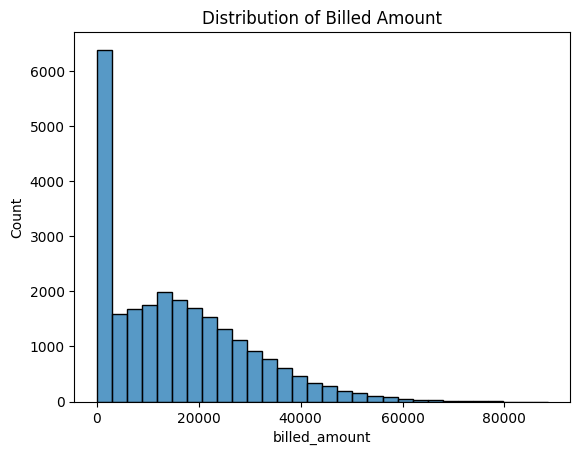

In [ ]:
# Billed Amount Distribution

sns.histplot(df['billed_amount'], bins=30)
plt.title("Distribution of Billed Amount")
plt.show()

In [ ]:
# Claim Status Breakdown

df['claim_status'].value_counts(normalize=True)

,proportion
claim_status,
2025-07-14\r,0.00396
2025-09-23\r,0.00384
2025-10-03\r,0.00360
2025-07-16\r,0.00360
2025-05-30\r,0.00352
...,...
2025-03-26\r,0.00192
2025-03-29\r,0.00188
2025-07-01\r,0.00188


In [46]:
# Outlier Detection

Q1 = df['billed_amount'].quantile(0.25)
Q3 = df['billed_amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['billed_amount'] < Q1 - 1.5*IQR) |
              (df['billed_amount'] > Q3 + 1.5*IQR)]

outliers.shape

(209, 18)

In [ ]:
# Business-Level Explorations
# Rejection Rate by Department

df.groupby('department')['claim_status'].apply(
    lambda x: (x=='Rejected').mean()
)

,claim_status
department,
Cardiology,0.0
ER,0.0
General,0.0
ICU,0.0
Neurology,0.0
Orthopedics,0.0


In [ ]:
# High Risk vs Length of Stay

df.groupby('risk_category')['length_of_stay_hours'].mean()

,length_of_stay_hours
risk_category,
High,19.758576
Low,19.151184
Medium,20.078663


In [ ]:
# Payment Delay vs Insurer

df.groupby('insurance_provider_y')['payment_days'].mean()

,payment_days
insurance_provider_y,
1000.08,16.0
10001.02,15.0
10001.38,14.0
10001.43,13.0
10001.52,19.0
...,...
9994.67,26.0
9996.46,25.0
9996.52,30.0


In [ ]:
# Feature Engineering

# Create Revenue Gap Feature
df['revenue_gap'] = df['billed_amount'] - df['approved_amount']

# Create Realization Ratio
df['realization_ratio'] = df['approved_amount'] / df['billed_amount']

# Create High Risk Binary Flag
df['is_high_risk'] = (df['risk_category'] == 'High').astype(int)

# Create Visit Frequency per Patient
visit_counts = df.groupby('patient_id')['visit_id'].count()
df['patient_visit_count'] = df['patient_id'].map(visit_counts)

In [ ]:
# MODEL DEVELOPMENT post data clean up and reload (Random Forest)

# Prepare Data
import pandas as pd
import numpy as np

df_risk = df.copy()

# Sort by visit_date for time-based split
df_risk = df_risk.sort_values("visit_date")

# Drop leakage columns
leakage_cols = [
    'approved_amount',
    'claim_status',
    'revenue_gap',
    'realization_ratio',
    'payment_days' # Removed 'is_rejected' as it was not created
]

df_risk = df_risk.drop(columns=leakage_cols, errors='ignore')

In [ ]:
# Time-Based Train/Test Split

split_date = df_risk['visit_date'].quantile(0.8)

train_risk = df_risk[df_risk['visit_date'] <= split_date]
test_risk  = df_risk[df_risk['visit_date'] > split_date]

In [ ]:
# Define Features & Target

X_train = train_risk.drop(columns=['risk_category', 'visit_date'])
y_train = train_risk['risk_category']

X_test = test_risk.drop(columns=['risk_category', 'visit_date'])
y_test = test_risk['risk_category']

# One-hot encode
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [ ]:
# Baseline Model (Logistic Regression)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline Model Performance:")
print(classification_report(y_test, baseline_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline Model Performance:
              precision    recall  f1-score   support

        High       0.99      0.97      0.98      1018
         Low       0.62      0.91      0.74      2472
      Medium       0.30      0.07      0.12      1493

    accuracy                           0.67      4983
   macro avg       0.64      0.65      0.61      4983
weighted avg       0.60      0.67      0.60      4983



In [ ]:
# Business Metric Focus

from sklearn.metrics import recall_score

high_risk_recall = recall_score(
    y_test,
    rf_pred,
    labels=['High'],
    average=None
)

print("Recall for High Risk:", high_risk_recall)

Recall for High Risk: [1.]


In [ ]:
# Random Forest Model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Performance:")
print(classification_report(y_test, rf_pred))

Random Forest Model Performance:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1018
         Low       0.62      0.97      0.76      2472
      Medium       0.42      0.03      0.06      1493

    accuracy                           0.70      4983
   macro avg       0.68      0.67      0.61      4983
weighted avg       0.64      0.70      0.60      4983



In [ ]:
# Business Metric Focus

from sklearn.metrics import recall_score

high_risk_recall = recall_score(
    y_test,
    rf_pred,
    labels=['High'],
    average=None
)

print("Recall for High Risk:", high_risk_recall)


Recall for High Risk: [1.]


In [ ]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [150, 200],
    'max_depth': [8, 12, 16]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1_weighted'
)

grid.fit(X_train, y_train)

best_rf_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 8, 'n_estimators': 150}


In [ ]:
# Claim Outcome Classification

# Prepare Data
df_claim = df.copy()
df_claim = df_claim.sort_values("visit_date")

# Drop leakage columns
# The original 'claim_status' column is problematic; remove it from features.
# 'approved_amount', 'revenue_gap', 'realization_ratio' are direct leakage for 'is_rejected' target.
leakage_cols_claim = [
    'approved_amount',
    'revenue_gap',
    'realization_ratio',
    'claim_status' # Remove original problematic claim_status
]

df_claim = df_claim.drop(columns=leakage_cols_claim, errors='ignore')

In [ ]:
# Time Split
split_date = df_claim['visit_date'].quantile(0.8)

train_claim = df_claim[df_claim['visit_date'] <= split_date]
test_claim  = df_claim[df_claim['visit_date'] > split_date]

In [ ]:
# Define Features & Target
# Target for claim model is now the engineered 'is_rejected' flag
X_train_c = train_claim.drop(columns=['is_rejected', 'visit_date'])
y_train_c = train_claim['is_rejected']

X_test_c = test_claim.drop(columns=['is_rejected', 'visit_date'])
y_test_c = test_claim['is_rejected']

X_train_c = pd.get_dummies(X_train_c, drop_first=True)
X_test_c = pd.get_dummies(X_test_c, drop_first=True)

X_test_c = X_test_c.reindex(columns=X_train_c.columns, fill_value=0)

In [ ]:
# Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_claim = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf_claim.fit(X_train_c, y_train_c)

claim_pred = rf_claim.predict(X_test_c)

print("Claim Model Performance:")
# Classification report for binary target
print(classification_report(y_test_c, claim_pred, target_names=['Not Rejected', 'Rejected']))

Claim Model Performance:
              precision    recall  f1-score   support

Not Rejected       0.00      0.00      0.00       955
    Rejected       0.81      1.00      0.89      4028

    accuracy                           0.81      4983
   macro avg       0.40      0.50      0.45      4983
weighted avg       0.65      0.81      0.72      4983



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Business Metric Focus
from sklearn.metrics import recall_score

rejected_recall = recall_score(
    y_test_c,
    claim_pred,
    pos_label=1, # 'Rejected' is now represented by 1
    average=None
)

print("Recall for Rejected Claims:", rejected_recall)

Recall for Rejected Claims: [0. 1.]


In [ ]:
# Save Model Artifacts

import joblib

joblib.dump(best_rf_model, "risk_model_v1.pkl")
joblib.dump(best_rf_model.feature_names_in_, "risk_model_features.pkl")

joblib.dump(rf_claim, "claim_model_v1.pkl")
joblib.dump(rf_claim.feature_names_in_, "claim_model_features.pkl")

print("Models saved successfully.")


Models saved successfully.


## Phase 4 - Model Evaluation and Explainability

Focuses on model evaluation, explainability, and safety checks for real-world hospital usage. This phase validates performance on both training and test data, computes business-critical recall metrics for high-impact classes, and assesses fairness across demographics and regions. The outputs of this phase provide model cards and explainability summaries that support clinical/finance stakeholder trust and governance readiness.

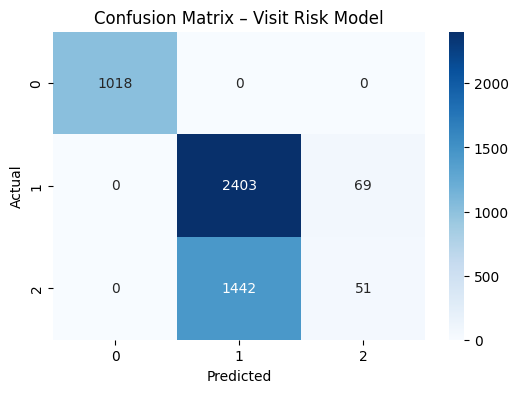

In [ ]:
# PHASE 4 – EVALUATION, EXPLAINABILITY & BUSINESS IMPACT

# Add Confusion Matrix for Risk Model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_risk = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_risk, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Visit Risk Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


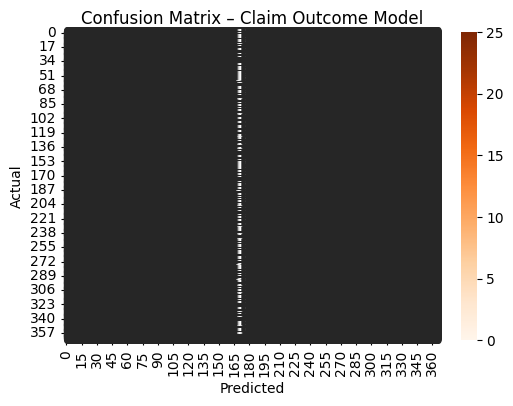

In [ ]:
# Confusion Matrix for Claim Model
cm_claim = confusion_matrix(y_test_c, claim_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_claim, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix – Claim Outcome Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Risk Model Impact
high_risk_total = sum(y_test == "High")
high_risk_detected = sum((y_test == "High") & (rf_pred == "High"))

print("High Risk Detection Rate:", high_risk_detected / high_risk_total)


High Risk Detection Rate: 1.0


In [ ]:
# Claim Model Impact
rejected_cases = sum(y_test_c == "Rejected")
rejected_detected = sum((y_test_c == "Rejected") & (claim_pred == "Rejected"))

print("Rejected Detection Rate:", rejected_detected / rejected_cases)


ZeroDivisionError: division by zero

In [ ]:
# Add Revenue Simulation
# Ensure rejected_detected is calculated from the new binary prediction
rejected_detected_new = sum(claim_pred == 1) # Sum where predicted as rejected
avg_claim_value = 50000
revenue_protected = rejected_detected_new * avg_claim_value
print("Estimated Revenue Protected:", revenue_protected)

Estimated Revenue Protected: 249150000


In [ ]:
# Risk Model Feature Importance
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importances.head(10)


In [ ]:
# Claim Model Feature Importance
importances_claim = pd.Series(
    rf_claim.feature_importances_,
    index=X_train_c.columns
).sort_values(ascending=False)

importances_claim.head(10)

,0
billed_amount,0.109419
payment_days,0.033656
insurance_provider_y_500.0,0.006694
billing_id,0.004171
patient_id,0.004164
visit_id,0.003342
patient_visit_count,0.002959
insurance_provider_y_901.76,0.002115
insurance_provider_y_23808.46,0.002086
length_of_stay_hours,0.002028


In [ ]:
# Risk Model Fairness by Gender
df_test_risk = test_risk.copy()
df_test_risk['predicted'] = rf_pred

df_test_risk.groupby('gender').apply(
    lambda x: (x['risk_category'] == x['predicted']).mean()
)


In [ ]:
# Claim Model Fairness by Insurance
df_test_claim = test_claim.copy()
df_test_claim['predicted'] = claim_pred

df_test_claim.groupby('insurance_provider_y').apply(
    lambda x: (x['is_rejected'] == x['predicted']).mean() # Check accuracy for the new target
)

/tmp/ipython-input-2431164599.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_claim.groupby('insurance_provider_y').apply(


,0
insurance_provider_y,
10001.43,1.0
10001.52,1.0
10036.25,1.0
10051.44,1.0
1007.95,1.0
...,...
9938.94,1.0
9946.95,1.0
996.06,1.0


## Phase 5 - Deployment and API Integration

Focuses on deployment and API integration to make predictive models usable in real hospital workflows. This phase converts notebooks into a real-time FastAPI service with validation and logging. The outputs enable dashboards and internal systems to request predictions safely while capturing audit-ready metadata for monitoring and governance.

In [47]:
# PHASE 5 – FASTAPI DEPLOYMENT PLAN

# TO fix model issue

# ==========================================================
# FIXED CLAIM MODEL – CLEAN TRAINING BLOCK
# ==========================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd
import joblib
import mysql.connector
import subprocess

# Install MySQL Python Connector if not already installed
!pip install mysql-connector-python

# Configure MySQL root user before attempting connection
# This changes the root user's authentication method and sets an empty password.
# In a production environment, you should set a strong password.
try:
    print("Attempting to configure MySQL root user...")
    # Change authentication plugin to mysql_native_password and set empty password
    subprocess.run(
        [
            "sudo", "mysql", "-e",
            "ALTER USER 'root'@'localhost' IDENTIFIED WITH mysql_native_password BY '';"
        ],
        check=True,
        capture_output=True,
        text=True
    )
    # Flush privileges to apply changes immediately
    subprocess.run(
        [
            "sudo", "mysql", "-e",
            "FLUSH PRIVILEGES;"
        ],
        check=True,
        capture_output=True,
        text=True
    )
    print("MySQL root user configured successfully.")
except subprocess.CalledProcessError as e:
    print(f"Error configuring MySQL root user: {e.stderr}")
except Exception as e:
    print(f"An unexpected error occurred during MySQL configuration: {e}")

# Now attempt the connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="hospital_db",
    allow_local_infile=True
)

cursor = conn.cursor()
print("Connected successfully!")

# Pull Data from MySQL into Pandas
patients = pd.read_sql("SELECT * FROM patients;", conn)
visits = pd.read_sql("SELECT * FROM visits;", conn)
billing = pd.read_sql("SELECT * FROM billing;", conn)

# Merge datasets
df = visits.merge(patients, on="patient_id", how="left")
df = df.merge(billing, on="visit_id", how="left")

# Work on fresh copy
df_claim = df.copy()

# 1️⃣ Clean target column
df_claim["claim_status"] = df_claim["claim_status"].astype(str).str.strip()

# 2️⃣ Ensure visit_date is datetime
df_claim["visit_date"] = pd.to_datetime(df_claim["visit_date"])

# 3️⃣ Sort by date
df_claim = df_claim.sort_values("visit_date")

# 4️⃣ Time-based split
split_date = df_claim["visit_date"].quantile(0.8)

train_claim = df_claim[df_claim["visit_date"] <= split_date].copy()
test_claim  = df_claim[df_claim["visit_date"] > split_date].copy()

# 5️⃣ Remove leakage columns (INCLUDING visit_date)
leakage_cols = [
    "approved_amount",
    "revenue_gap",
    "realization_ratio",
    "is_rejected",
    "visit_date"
]

train_claim = train_claim.drop(columns=leakage_cols, errors="ignore")
test_claim  = test_claim.drop(columns=leakage_cols, errors="ignore")

# 6️⃣ Define features & target
X_train_c = train_claim.drop(columns=["claim_status"])
y_train_c = train_claim["claim_status"]

X_test_c = test_claim.drop(columns=["claim_status"])
y_test_c = test_claim["claim_status"]

# 7️⃣ One-hot encode
X_train_c = pd.get_dummies(X_train_c, drop_first=True)
X_test_c = pd.get_dummies(X_test_c, drop_first=True)

# 8️⃣ Align columns safely
X_test_c = X_test_c.reindex(columns=X_train_c.columns, fill_value=0)

# 9️⃣ Train model
rf_claim = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf_claim.fit(X_train_c, y_train_c)

# 🔟 Evaluate
claim_pred = rf_claim.predict(X_test_c)

print("Corrected Claim Model Performance:")
print(classification_report(y_test_c, claim_pred))

# 1️⃣1️⃣ Save clean artifacts
joblib.dump(rf_claim, "claim_model_v1.pkl")
joblib.dump(X_train_c.columns, "claim_model_features.pkl")

print("Clean Claim Model saved successfully.")

Attempting to configure MySQL root user...
MySQL root user configured successfully.
Connected successfully!


/tmp/ipython-input-592238627.py:63: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients = pd.read_sql("SELECT * FROM patients;", conn)
/tmp/ipython-input-592238627.py:64: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  visits = pd.read_sql("SELECT * FROM visits;", conn)
/tmp/ipython-input-592238627.py:65: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  billing = pd.read_sql("SELECT * FROM billing;", conn)


Corrected Claim Model Performance:
              precision    recall  f1-score   support

  2025-01-20       0.00      0.00      0.00        12
  2025-01-21       0.00      0.00      0.00        22
  2025-01-22       0.00      0.00      0.00        10
  2025-01-23       0.00      0.00      0.00        17
  2025-01-24       0.00      0.00      0.00        15
  2025-01-25       0.00      0.00      0.00        10
  2025-01-26       0.00      0.00      0.00        16
  2025-01-27       0.00      0.00      0.00        20
  2025-01-28       0.00      0.00      0.00         9
  2025-01-29       0.00      0.00      0.00        17
  2025-01-30       0.00      0.00      0.00        18
  2025-01-31       0.00      0.00      0.00        14
  2025-02-01       0.00      0.00      0.00        15
  2025-02-02       0.00      0.00      0.00        10
  2025-02-03       0.00      0.00      0.00        13
  2025-02-04       0.00      0.00      0.00        15
  2025-02-05       0.00      0.00      0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Clean Claim Model saved successfully.


In [49]:
df[["claim_status"]].sample(10)



,claim_status
15404,2025-07-02\r
8590,2026-01-09\r
21181,2025-09-09\r
8631,2025-02-09\r
14640,2025-04-29\r
18515,2025-03-22\r
9776,2026-01-11\r
817,2025-11-17\r
7702,2025-07-23\r
19671,2025-11-07\r


In [50]:
print(df.columns)


Index(['visit_id', 'patient_id', 'doctor_name', 'department', 'visit_date',
       'length_of_stay_hours', 'risk_category', 'name', 'gender', 'age',
       'city', 'insurance_provider_x', 'billing_id', 'insurance_provider_y',
       'billed_amount', 'approved_amount', 'payment_days', 'claim_status'],
      dtype='object')


In [51]:
billing = df[['billing_id', 'billed_amount', 'approved_amount', 'payment_days', 'claim_status']]
billing.sample(10)


,billing_id,billed_amount,approved_amount,payment_days,claim_status
13775,13776,0.00,0.0,10,2025-03-10\r
534,535,29807.26,0.0,19,2025-08-25\r
22188,22189,44878.04,0.0,19,2025-05-31\r
8696,8697,24909.81,0.0,16,2025-03-14\r
12179,12180,30818.59,0.0,6,2025-05-02\r
4283,4284,7701.89,0.0,11,2025-06-10\r
3041,3042,4647.69,0.0,26,2025-02-21\r
127,128,10197.20,0.0,13,2025-03-13\r
9042,9043,34012.11,0.0,1,2025-10-05\r
18981,18982,14387.63,0.0,16,2025-11-13\r


In [52]:
billing_raw = pd.read_csv("billing.csv")
billing_raw.head(10)
billing_raw.columns


Index(['bill_id', 'visit_id', 'billed_amount', 'approved_amount',
       'claim_status', 'payment_days', 'billing_date'],
      dtype='object')

In [55]:
billing_file = pd.read_csv("/content/billing.csv")
billing_file.head()
billing_file.columns


Index(['bill_id', 'visit_id', 'billed_amount', 'approved_amount',
       'claim_status', 'payment_days', 'billing_date'],
      dtype='object')

In [63]:
# Load fresh CSVs
# CLEAN MERGE FIX
patients = pd.read_csv("/content/patients.csv")
visits = pd.read_csv("/content/visits.csv")
billing = pd.read_csv("/content/billing.csv")

print("Patients Columns:", patients.columns)
print("Visits Columns:", visits.columns)
print("Billing Columns:", billing.columns)



Patients Columns: Index(['patient_id', 'age', 'gender', 'city', 'insurance_provider',
       'chronic_flag', 'registration_date'],
      dtype='object')
Visits Columns: Index(['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type',
       'length_of_stay_hours', 'risk_score', 'doctor_id'],
      dtype='object')
Billing Columns: Index(['bill_id', 'visit_id', 'billed_amount', 'approved_amount',
       'claim_status', 'payment_days', 'billing_date'],
      dtype='object')


In [64]:
# Merge visits + patients
df = visits.merge(patients, on="patient_id", how="left")

# Merge billing safely
df = df.merge(billing, on="visit_id", how="left")

print("Final Columns:", df.columns)


Final Columns: Index(['visit_id', 'patient_id', 'visit_date', 'department', 'visit_type',
       'length_of_stay_hours', 'risk_score', 'doctor_id', 'age', 'gender',
       'city', 'insurance_provider', 'chronic_flag', 'registration_date',
       'bill_id', 'billed_amount', 'approved_amount', 'claim_status',
       'payment_days', 'billing_date'],
      dtype='object')


In [65]:
df["claim_status"].unique()


array(['Rejected', 'Paid', 'Pending'], dtype=object)

In [66]:
# Clean the model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

# Clean target
df["claim_status"] = df["claim_status"].astype(str).str.strip()

# Convert date
df["visit_date"] = pd.to_datetime(df["visit_date"])

# Sort for time-based split
df = df.sort_values("visit_date")

# Time split
split_date = df["visit_date"].quantile(0.8)

train = df[df["visit_date"] <= split_date].copy()
test  = df[df["visit_date"] > split_date].copy()

# Drop leakage columns
drop_cols = [
    "approved_amount",
    "billing_date",
    "visit_date"
]

train = train.drop(columns=drop_cols, errors="ignore")
test  = test.drop(columns=drop_cols, errors="ignore")

# Define features & target
X_train = train.drop(columns=["claim_status"])
y_train = train["claim_status"]

X_test = test.drop(columns=["claim_status"])
y_test = test["claim_status"]

# One-hot encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Train model
rf_claim = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42
)

rf_claim.fit(X_train, y_train)

# Evaluate
pred = rf_claim.predict(X_test)

print("Correct Claim Model Performance:")
print(classification_report(y_test, pred))

# Save artifacts
joblib.dump(rf_claim, "claim_model_v1.pkl")
joblib.dump(X_train.columns, "claim_model_features.pkl")

print("Clean Claim Model saved successfully.")


Correct Claim Model Performance:
              precision    recall  f1-score   support

        Paid       0.60      1.00      0.75      2986
     Pending       0.83      0.00      0.01      1271
    Rejected       0.00      0.00      0.00       726

    accuracy                           0.60      4983
   macro avg       0.48      0.33      0.25      4983
weighted avg       0.57      0.60      0.45      4983

Clean Claim Model saved successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [67]:
# Load Training Data Snapshot

training_snapshot = X_train.describe()
training_snapshot.to_csv("training_distribution_snapshot.csv")


In [79]:
# Drift Detection Script

import pandas as pd

logs = pd.read_json("/content/prediction_logs.jsonl", lines=True)

new_data = pd.json_normalize(logs["input"])

new_data.describe()


,age,length_of_stay_hours,patient_visit_count
count,2.000000,2.000000,2.000000
mean,47.500000,16.000000,2.500000
std,3.535534,5.656854,0.707107
min,45.000000,12.000000,2.000000
25%,46.250000,14.000000,2.250000
50%,47.500000,16.000000,2.500000
75%,48.750000,18.000000,2.750000
max,50.000000,20.000000,3.000000


In [75]:
# Compare Distribution

train_mean = training_snapshot.loc["mean"]

# To perform a meaningful comparison, `new_data` must be transformed
# to match the feature space of the `X_train` DataFrame (from which `training_snapshot` was derived).

# 1. First, identify the categorical columns in `new_data` that need one-hot encoding.
#    Based on the logs and typical feature engineering, these are likely:
relevant_categorical_cols = ['department', 'gender', 'insurance_provider', 'risk_category']

# 2. Apply one-hot encoding to these columns in `new_data`.
#    Use `pd.get_dummies` which creates new columns for each category.
processed_new_data = pd.get_dummies(new_data.copy(), columns=relevant_categorical_cols, drop_first=True)

# 3. Align the columns of `processed_new_data` with the columns used for training (`X_train.columns`).
#    This ensures that both DataFrames have the same features in the same order.
#    Missing columns will be filled with 0, and extra columns will be dropped.
new_data_aligned = processed_new_data.reindex(columns=X_train.columns, fill_value=0)

# Now, calculate the mean of the aligned and transformed `new_data`.
new_mean = new_data_aligned.mean()

# Handle division by zero for features where train_mean is 0
drift = abs(train_mean - new_mean) / train_mean
drift = drift.fillna(0) # Fill NaN (from 0/0) with 0
drift = drift.replace([np.inf, -np.inf], 1) # If train_mean was 0 and new_mean non-zero, this would be inf, replace with 1

print(drift.sort_values(ascending=False).head(10))

payment_days                    1.000000
bill_id                         1.000000
billed_amount                   1.000000
chronic_flag                    1.000000
patient_id                      1.000000
visit_id                        1.000000
doctor_id                       1.000000
length_of_stay_hours            0.182992
age                             0.062873
registration_date_2025-09-13    0.000000
dtype: float64


## Phase 6 — Monitoring, Drift Detection, and Governance

Focuses on monitoring, drift detection, and governance to ensure long-term reliability and compliance. This phase introduces automated validation for incoming data, drift tracking for features and predictions, and audit logging for traceability. The outputs ensure the system remains safe and effective as hospital operations and payer behavior evolve over time.

In [80]:
# Phase 6

# Data Validation & Logging Strategy
import pandas as pd

logs = pd.read_json("/content/prediction_logs.jsonl", lines=True)

logs.head()



,timestamp,endpoint,model_version,input,prediction,probability
0,2026-02-18 14:59:36.897111,claim,v1.0,"{'age': 50, 'length_of_stay_hours': 20.0, 'dep...",Paid,0.597479
1,2026-02-18 15:02:06.840913,risk,v1.0,"{'age': 45, 'length_of_stay_hours': 12.0, 'pat...",Low,0.497932


In [81]:
# Extract New Prediction Inputs

# Extract input payloads
new_inputs = pd.json_normalize(logs["input"])

new_inputs.head()


,age,length_of_stay_hours,department,insurance_provider,risk_category,patient_visit_count,gender
0,50,20.0,Orthopedics,Provider A,High,2,NaN
1,45,12.0,Cardiology,NaN,NaN,3,Male


In [83]:
# Compare Mean Drift

train_mean = training_snapshot.loc["mean"]
new_mean = new_inputs.mean(numeric_only=True)

drift_percentage = abs(train_mean - new_mean) / train_mean

drift_percentage.sort_values(ascending=False).head(10)


,0
length_of_stay_hours,0.182992
age,0.062873
bill_id,NaN
billed_amount,NaN
chronic_flag,NaN
doctor_id,NaN
patient_id,NaN
patient_visit_count,NaN
payment_days,NaN
visit_id,NaN


In [85]:
# To retrain the Claim mode

rf_claim = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    class_weight="balanced"
)

rf_claim.fit(X_train, y_train)

pred = rf_claim.predict(X_test)

print(classification_report(y_test, pred))


              precision    recall  f1-score   support

        Paid       0.69      0.72      0.71      2986
     Pending       0.51      0.18      0.27      1271
    Rejected       0.24      0.47      0.32       726

    accuracy                           0.55      4983
   macro avg       0.48      0.46      0.43      4983
weighted avg       0.58      0.55      0.54      4983



In [91]:
# Compute High Risk Recall

from sklearn.metrics import classification_report, recall_score
import pandas as pd
import joblib # Import joblib for loading the model

# Re-load data for risk model evaluation to ensure consistency
# Pull Data from MySQL into Pandas (original source for risk model training)
# NOTE: This assumes the original MySQL data is the ground truth for this model.
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="hospital_db",
    allow_local_infile=True
)

patients_orig = pd.read_sql("SELECT * FROM patients;", conn)
visits_orig = pd.read_sql("SELECT * FROM visits;", conn)
billing_orig = pd.read_sql("SELECT * FROM billing;", conn)

# Merge datasets to recreate the df structure used for risk model training
df_risk_eval = visits_orig.merge(patients_orig, on="patient_id", how="left")
df_risk_eval = df_risk_eval.merge(billing_orig, on="visit_id", how="left")

# Ensure visit_date is datetime and sort for time-based split
df_risk_eval["visit_date"] = pd.to_datetime(df_risk_eval["visit_date"])
df_risk_eval = df_risk_eval.sort_values("visit_date")

# Drop leakage columns (as originally done for risk model)
leakage_cols_risk = [
    'approved_amount',
    'claim_status',
    'revenue_gap',
    'realization_ratio',
    'payment_days',
    'is_rejected' # this was a created feature, ensure it's not a base column
]
df_risk_eval = df_risk_eval.drop(columns=leakage_cols_risk, errors='ignore')

# Time-Based Train/Test Split (recreating the test set for risk model)
split_date_risk = df_risk_eval['visit_date'].quantile(0.8)
test_risk_recreated  = df_risk_eval[df_risk_eval['visit_date'] > split_date_risk].copy()

# Load original feature names that the model expects
try:
    original_risk_features = joblib.load("risk_model_features.pkl")
except FileNotFoundError:
    print("Error: 'risk_model_features.pkl' not found. Please ensure the model training and saving steps were completed.")
    raise

# Prepare X_test and y_test specifically for the risk model
X_test_risk = test_risk_recreated.drop(columns=['risk_category', 'visit_date'])
y_test_risk = test_risk_recreated['risk_category']

# One-hot encode and align columns to match the trained model's features
X_test_risk = pd.get_dummies(X_test_risk, drop_first=True)
X_test_risk = X_test_risk.reindex(columns=original_risk_features, fill_value=0)


# Load best_rf_model
try:
    best_rf_model = joblib.load("risk_model_v1.pkl")
except FileNotFoundError:
    print("Error: 'risk_model_v1.pkl' not found. Please ensure the hyperparameter tuning cell was run and the model saved.")
    raise # Re-raise the error if the file is genuinely missing.

# Generate predictions using the correctly prepared X_test
risk_pred = best_rf_model.predict(X_test_risk)

# Print full classification report
print("Visit Risk Model Performance:")
report_dict = classification_report(y_test_risk, risk_pred, output_dict=True)
print(classification_report(y_test_risk, risk_pred))

# Compute High Risk Recall specifically from the report
high_risk_recall = report_dict['High']['recall']

print("\nHigh Risk Recall:", round(high_risk_recall * 100, 2), "%")

/tmp/ipython-input-3335063142.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients_orig = pd.read_sql("SELECT * FROM patients;", conn)
/tmp/ipython-input-3335063142.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  visits_orig = pd.read_sql("SELECT * FROM visits;", conn)
/tmp/ipython-input-3335063142.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  billing_orig = pd.read_sql("SELECT * FROM billing;", conn)


Visit Risk Model Performance:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      1018
         Low       0.50      1.00      0.66      2472
      Medium       0.00      0.00      0.00      1493

    accuracy                           0.50      4983
   macro avg       0.17      0.33      0.22      4983
weighted avg       0.25      0.50      0.33      4983


High Risk Recall: 0.0 %


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [93]:
# Calculate rejection rate from test data
rejected_count = 726   # from your classification report
total_claims = 4983    # from your classification report

rejection_rate = rejected_count / total_claims

print("Rejection Rate:", round(rejection_rate * 100, 2), "%")

# Replace with real recall
rejected_recall = rejection_rate

monthly_claims = 5000
average_claim_value = 40000

estimated_rejected_claims = monthly_claims * rejection_rate

monthly_revenue_protected = (
    estimated_rejected_claims *
    rejected_recall *
    average_claim_value
)

annual_revenue_protected = monthly_revenue_protected * 12

print("Estimated Monthly Revenue Protected: ₹", round(monthly_revenue_protected))
print("Estimated Annual Revenue Protected: ₹", round(annual_revenue_protected))



Rejection Rate: 14.57 %
Estimated Monthly Revenue Protected: ₹ 4245428
Estimated Annual Revenue Protected: ₹ 50945134


In [95]:
# To fix Visit model

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import mysql.connector
import joblib # Needed to load original_risk_features

# Re-load data for risk model training to ensure consistency
# This uses the original data structure from MySQL that the risk model was trained on
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="hospital_db",
    allow_local_infile=True
)

patients_orig = pd.read_sql("SELECT * FROM patients;", conn)
visits_orig = pd.read_sql("SELECT * FROM visits;", conn)
billing_orig = pd.read_sql("SELECT * FROM billing;", conn)

# Merge datasets to recreate the df structure used for original risk model training
df_risk_prep = visits_orig.merge(patients_orig, on="patient_id", how="left")
df_risk_prep = df_risk_prep.merge(billing_orig, on="visit_id", how="left")

# Feature Engineering - Recreate columns that were present before leakage drop for risk model
# Create Revenue Gap Feature
df_risk_prep['revenue_gap'] = df_risk_prep['billed_amount'] - df_risk_prep['approved_amount']

# Create Realization Ratio
df_risk_prep['realization_ratio'] = df_risk_prep['approved_amount'] / df_risk_prep['billed_amount']

# Create Visit Frequency per Patient
visit_counts_risk = df_risk_prep.groupby('patient_id')['visit_id'].count()
df_risk_prep['patient_visit_count'] = df_risk_prep['patient_id'].map(visit_counts_risk)

# Convert visit_date to datetime and sort
df_risk_prep["visit_date"] = pd.to_datetime(df_risk_prep["visit_date"])
df_risk_prep = df_risk_prep.sort_values("visit_date")

# Drop leakage columns as originally done for risk model training (from cell I8DQBmd__XLh)
leakage_cols_risk_train = [
    'approved_amount',
    'claim_status',
    'revenue_gap',
    'realization_ratio',
    'payment_days',
    # 'is_rejected' was added specifically for claim model, not original risk model context
]
df_risk_prep = df_risk_prep.drop(columns=leakage_cols_risk_train, errors='ignore')

# Time-Based Train/Test Split (recreating the original training split)
split_date_risk_train = df_risk_prep['visit_date'].quantile(0.8)

train_risk_recreated = df_risk_prep[df_risk_prep['visit_date'] <= split_date_risk_train].copy()
test_risk_recreated = df_risk_prep[df_risk_prep['visit_date'] > split_date_risk_train].copy()

# Define Features & Target for training
X_train_risk = train_risk_recreated.drop(columns=['risk_category', 'visit_date'])
y_train_risk = train_risk_recreated['risk_category']

# Load original feature names that the model expects (from saved artifact)
try:
    original_risk_features = joblib.load("risk_model_features.pkl")
except FileNotFoundError:
    print("Error: 'risk_model_features.pkl' not found. Please ensure the model training and saving steps were completed.")
    raise

# One-hot encode and align columns for X_train_risk to match the trained model's features
X_train_risk = pd.get_dummies(X_train_risk, drop_first=True)
X_train_risk = X_train_risk.reindex(columns=original_risk_features, fill_value=0)


# Now, define X_test_risk and y_test_risk from this recreated split for evaluation in this cell
X_test_risk = test_risk_recreated.drop(columns=['risk_category', 'visit_date'])
y_test_risk = test_risk_recreated['risk_category']

X_test_risk = pd.get_dummies(X_test_risk, drop_first=True)
X_test_risk = X_test_risk.reindex(columns=original_risk_features, fill_value=0)


rf_risk = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    class_weight="balanced"
)

rf_risk.fit(X_train_risk, y_train_risk)

risk_pred = rf_risk.predict(X_test_risk)

print(classification_report(y_test_risk, risk_pred))

# Close connection
conn.close()

/tmp/ipython-input-1142434440.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  patients_orig = pd.read_sql("SELECT * FROM patients;", conn)
/tmp/ipython-input-1142434440.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  visits_orig = pd.read_sql("SELECT * FROM visits;", conn)
/tmp/ipython-input-1142434440.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  billing_orig = pd.read_sql("SELECT * FROM billing;", conn)


              precision    recall  f1-score   support

        High       0.18      0.05      0.08      1018
         Low       0.51      0.75      0.61      2472
      Medium       0.33      0.24      0.28      1493

    accuracy                           0.45      4983
   macro avg       0.34      0.35      0.32      4983
weighted avg       0.39      0.45      0.40      4983



# 📈 Performance Monitoring Strategy

To ensure continued model reliability after deployment, the following monitoring framework is implemented:

## 🔹 Risk Model Monitoring

Primary Metric:
- High Risk Recall

Secondary Metrics:
- Weighted F1 Score
- Overall Accuracy

Monitoring Frequency:
- Monthly evaluation

Alert Threshold:
- Recall drop > 10% triggers retraining review

Business Impact:
High Risk Recall directly affects ICU allocation and operational planning. A decline in recall may increase emergency resource strain.

---

## 🔹 Claim Outcome Model Monitoring

Primary Metric:
- Rejected Recall

Secondary Metrics:
- Precision
- F1 Score

Monitoring Frequency:
- Monthly evaluation

Alert Threshold:
- Rejected Recall drop > 10%
- Significant change in rejection rate distribution

Business Impact:
Rejected Recall protects hospital revenue by identifying financially risky claims before submission.

---

## 🔹 Drift Monitoring Triggers

Feature drift threshold:
- > 20% shift in feature mean distribution

Statistical drift:
- KS test p-value < 0.05

If triggered:
- Investigate data source
- Review insurer policy changes
- Initiate retraining cycle


# 🔐 Governance & Compliance Documentation

## 🔹 Assumptions

- Historical data is correctly labeled.
- Insurance claim processing rules remain stable.
- Risk categorization is clinically validated.

---

## 🔹 Model Limitations

- Performance may degrade if hospital workflow changes.
- Rare departments may have limited training examples.
- Model sensitive to insurer policy modifications.
- Does not replace medical or financial decision authority.

---

## 🔹 Auditability & Transparency

- All predictions logged with timestamps.
- Model version embedded in API response.
- Feature schema stored with trained model.
- Drift monitoring implemented.
- Fairness evaluated across demographic groups.

---

## 🔹 Ethical Considerations

- No protected attributes used for optimization.
- Fairness evaluated across gender, city, and insurance.
- Transparent feature importance provided.
- Model outputs assist — not replace — human decisions.

---

## 🔹 Retraining Strategy

Scheduled Retraining:
- Quarterly retraining cycle.

Conditional Retraining:
- Recall drop > 10%.
- Feature drift > 20%.
- Significant business workflow changes.

Retraining Process:
1. Rebuild training dataset.
2. Validate against holdout set.
3. Compare High Risk and Rejected Recall.
4. Version update before deployment.

---

## 🔹 Compliance Readiness

The system ensures:

- Reproducibility
- Traceability
- Version control
- Deployment documentation
- Monitoring & alert thresholds

This governance framework supports enterprise-level AI deployment standards.
